<a href="https://colab.research.google.com/github/isaacmello-droid/introdu-o-a-analise-de-dados/blob/main/C%C3%B3pia_de_TRABALHO_FINAL_An%C3%A1lise_Explorat%C3%B3ria_Ci%C3%AAncia_de_Dados_Lucas_Isaac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ANÁLISE EXPLORATÓRIA SOBRE A PRODUÇÃO DE PETRÓLEO NO BRASIL (1997-2026) 🛢️🌍**
#**Isaac Sales Aguiar Mello**
---
Dataset obtido no Portal de Dados Abertos do Brasil: [Link do dataset](https://drive.google.com/file/d/1DN15R4RjkB-PsAK0cn8apvDPBYM0x83U/view?usp=sharing)

Base de dados de onde o dataset foi extraído: [Link da base de dados](https://dados.gov.br/dados/conjuntos-dados/producao-de-petroleo-e-gas-natural-por-estado-e-localizacao)

#**Introdução**
A transformação digital revolucionou a nossa capacidade de coletar e analisar informações em todas as áreas, gerando um imenso volume de dados disponíveis para a tomada de decisões. O grande desafio da Ciência de Dados é justamente transformar esses registros brutos em conhecimento útil e estratégico. É o que faremos hoje: através da Análise Exploratória de Dados, a primeira e mais crucial etapa desse processo, vamos investigar o histórico da produção de petróleo no Brasil. Nosso objetivo é traduzir milhares de dados abertos em insights claros, revelando os padrões geográficos e tecnológicos que movem o setor energético nacional.

Esses conteúdos estão divididos em 2 duas partes:
1. Análise e tratamento dos dados
2. Insights sobre algumas informações extraídas na primeira parte

#**Desenvolvimento 1° parte**

1. **IMPORTANDO AS BIBLIOTECAS E O DATASET**

In [54]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [55]:
df = pd.read_csv('/content/drive/MyDrive/DATASET - producao_petroleo_Brasil.csv', sep=';', encoding='utf-8')


2. **VIZUALIZANDO E DESCOBRINDO O TAMANHO DA BASE**

In [56]:
display(df)

,ANO,MÊS,GRANDE REGIÃO,UNIDADE DA FEDERAÇÃO,PRODUTO,LOCALIZAÇÃO,PRODUÇÃO
0,1997,JAN,REGIÃO NORTE,AMAZONAS,PETRÓLEO,TERRA,122200
1,1997,FEV,REGIÃO NORTE,AMAZONAS,PETRÓLEO,TERRA,124785
2,1997,MAR,REGIÃO NORTE,AMAZONAS,PETRÓLEO,TERRA,128177
3,1997,ABR,REGIÃO NORTE,AMAZONAS,PETRÓLEO,TERRA,124968
4,1997,MAI,REGIÃO NORTE,AMAZONAS,PETRÓLEO,TERRA,115710
...,...,...,...,...,...,...,...
7915,2026,AGO,REGIÃO SUL,PARANÁ,PETRÓLEO,MAR,0
7916,2026,SET,REGIÃO SUL,PARANÁ,PETRÓLEO,MAR,0
7917,2026,OUT,REGIÃO SUL,PARANÁ,PETRÓLEO,MAR,0
7918,2026,NOV,REGIÃO SUL,PARANÁ,PETRÓLEO,MAR,0


3. **CONFERINDO O PERÍODO DA ANÁLISE**


In [57]:
inicio =df['ANO'].min()
fim = df['ANO'].max()
print(f'{inicio} - {fim}')

1997 - 2026


4. **VERIFICANDO VALORES NULOS E O TIPO DOS DADOS**

In [58]:
df.isnull().sum()

,0
ANO,0
MÊS,0
GRANDE REGIÃO,0
UNIDADE DA FEDERAÇÃO,0
PRODUTO,0
LOCALIZAÇÃO,0
PRODUÇÃO,0


In [59]:
df.dtypes

,0
ANO,int64
MÊS,object
GRANDE REGIÃO,object
UNIDADE DA FEDERAÇÃO,object
PRODUTO,object
LOCALIZAÇÃO,object
PRODUÇÃO,object


convertendo a coluna 'PRODUÇÃO' para tipo numérico


In [60]:
df['PRODUÇÃO'] = df['PRODUÇÃO'].astype(str).str.replace(',', '.', regex=False).astype(float)

5. **ANÁLISANDO AS INFORMAÇÕES ESTATÍSTICAS SOBRE A PRODUÇÃO**

In [61]:
estatisticas_df = df[['PRODUÇÃO']].describe()
def formata_br(valor):
    valor_americano = f"{valor:,.2f}"
    return valor_americano.replace(',', 'X').replace('.', ',').replace('X', '.')
formato_tabela = estatisticas_df.style.format(formata_br)
display(formato_tabela)

,PRODUÇÃO
count,"7.920,00"
mean,"458.795,88"
std,"1.812.909,29"
min,"0,00"
25%,"0,00"
50%,"11.440,47"
75%,"96.774,21"
max,"18.028.299,72"


Média utilizando apenas os estados que produzem


In [62]:
#Descobrir a produção total de cada estado
producao_por_estado = df.groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum()

#Filtrar apenas os estados que produzem
estados_que_produzem = producao_por_estado[producao_por_estado > 0]

#Descobrir o número total desses estados produtores
numero_de_estados = len(estados_que_produzem)

#Pegar a produção total do país
producao_total_pais = df['PRODUÇÃO'].sum()

#Calculando a nova média
total_br = producao_total_pais / numero_de_estados

print(f"PRODUÇÃO TOTAL DO BRASIL: {total_br} m³")
print(f"QUANTIDADE DE ESTADOS PRODUTORES: {numero_de_estados}")
print(f"MÉDIA POR ESTADO PRODUTOR: {total_br} m³")

PRODUÇÃO TOTAL DO BRASIL: 330333030.54810184 m³
QUANTIDADE DE ESTADOS PRODUTORES: 11
MÉDIA POR ESTADO PRODUTOR: 330333030.54810184 m³


6. **INDENTIFICANDO OUTLIERS**

Visualização gráfica dos outliers

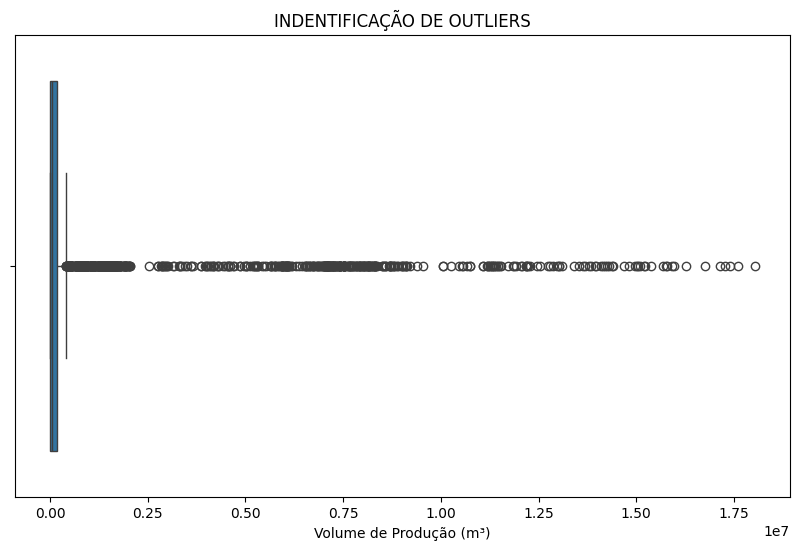

In [63]:
df_produtivo = df[df['PRODUÇÃO'] > 0]

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_produtivo['PRODUÇÃO'])

plt.title('INDENTIFICAÇÃO DE OUTLIERS')
plt.xlabel('Volume de Produção (m³)')
plt.show()

Indentificação dos maiores outliers

In [64]:
#Calculo do Primeiro e o Terceiro Quartil
Q1 = df_produtivo['PRODUÇÃO'].quantile(0.25)
Q3 = df_produtivo['PRODUÇÃO'].quantile(0.75)

#Calculo do IQR
IQR = Q3 - Q1

#Definição de um limite
limite_superior = Q3 + 1.5 * IQR

#Filtrar a base para nos mostrar apenas o que passa do limite
df_outliers = df_produtivo[df_produtivo['PRODUÇÃO'] > limite_superior]

#Ordenar do maior para o menor
df_outliers = df_outliers.sort_values(by='PRODUÇÃO', ascending=False)

# Formatando o número do limite_superior para o texto do print
limite_br = f"{limite_superior:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print(f"O limite normal de produção é até {limite_br} m³.")
print(f"EXISTEM {len(df_outliers)} OUTLIERS.")
print('-----------------------------------------------------')
print("5 MAIORES OUTLIERS: ")

def formata_br(valor):
    valor_americano = f"{valor:,.2f}"
    return valor_americano.replace(',', 'X').replace('.', ',').replace('X', '.')

tabela_final = df_outliers[['ANO', 'MÊS', 'UNIDADE DA FEDERAÇÃO', 'PRODUÇÃO']].head()

display(tabela_final.style.format({'PRODUÇÃO': formata_br}))

O limite normal de produção é até 415.386,89 m³.
EXISTEM 729 OUTLIERS.
-----------------------------------------------------
5 MAIORES OUTLIERS: 


,ANO,MÊS,UNIDADE DA FEDERAÇÃO,PRODUÇÃO
7694,2026,MAR,RIO DE JANEIRO,"18.028.299,72"
7487,2025,DEZ,RIO DE JANEIRO,"17.600.299,35"
7485,2025,OUT,RIO DE JANEIRO,"17.406.897,87"
7692,2026,JAN,RIO DE JANEIRO,"17.281.030,82"
7482,2025,JUL,RIO DE JANEIRO,"17.139.905,55"


#**Desenvolvimento 2° parte**

1. EVOLUÇÃO ANUAL DA PRODUÇÃO DE PETRÓLEO ONSHORE

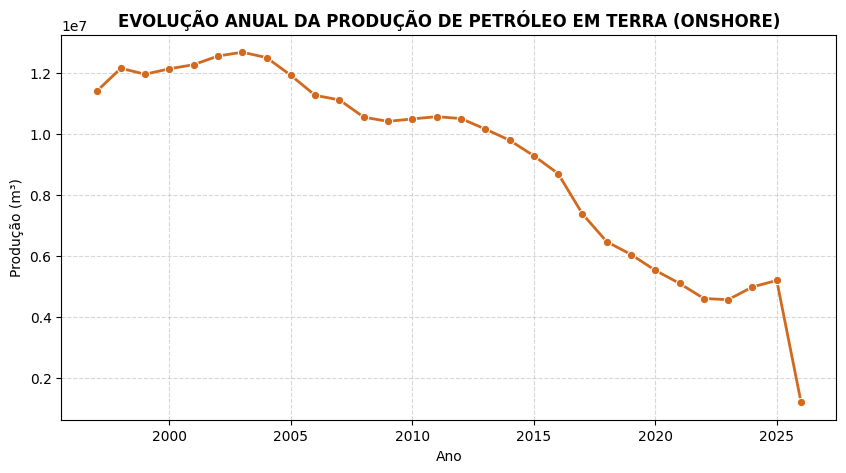

In [65]:

df_terra = df[df['LOCALIZAÇÃO'] == 'TERRA']

prod_terra_anual = df_terra.groupby('ANO')['PRODUÇÃO'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=prod_terra_anual, x='ANO', y='PRODUÇÃO', marker='o', color='chocolate', linewidth=2)

plt.title('EVOLUÇÃO ANUAL DA PRODUÇÃO DE PETRÓLEO EM TERRA (ONSHORE)', fontsize=12, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Produção (m³)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Conclusão da análise**


O Brasil possui uma curva histórica de crescimento extremamente sólida. Desde o final da década de 90 até 2025, a produção nacional se multiplicou, mostrando o amadurecimento do setor e o retorno dos investimentos de longo prazo. A queda drástica no último ponto do gráfico (2026) não é uma retração de mercado, mas sim o reflexo de um ano que ainda está em andamento (dados incompletos).

2. EVOLUÇÃO ANUAL DA PRODUÇÃO DE PETRÓLEO OFFSHORE

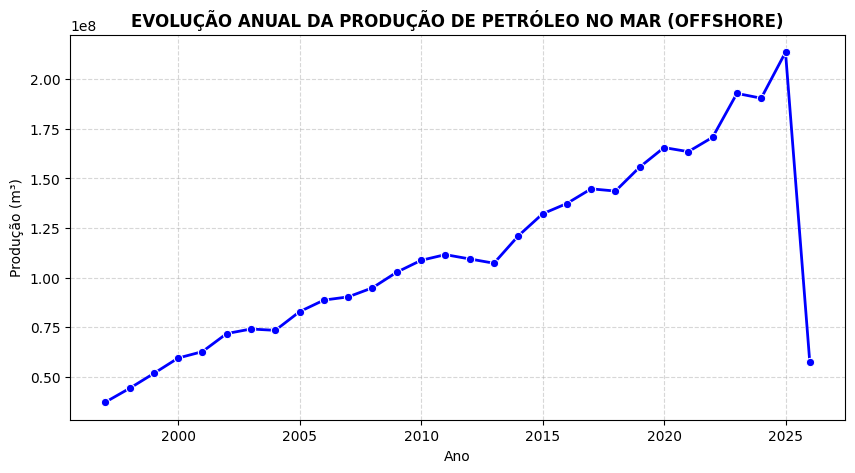

In [66]:
df_mar = df[df['LOCALIZAÇÃO'] == 'MAR']

prod_mar_anual = df_mar.groupby('ANO')['PRODUÇÃO'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=prod_mar_anual, x='ANO', y='PRODUÇÃO', marker='o', color='b', linewidth=2)

plt.title('EVOLUÇÃO ANUAL DA PRODUÇÃO DE PETRÓLEO NO MAR (OFFSHORE)', fontsize=12, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Produção (m³)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Conclusão da análise

Este gráfico escancara a "vocação marítima" do Brasil. Enquanto a produção em terra (onshore) se manteve estagnada e em patamares baixíssimos ao longo das décadas, a extração no mar (offshore) decolou de forma exponencial. Isso comprova o sucesso das tecnologias de exploração em águas profundas e do Pré-Sal, que são os verdadeiros motores da nossa indústria.

3. MAIORES PRODUTORES: TERRA VS MAR

In [67]:
lider_terra = df[df['LOCALIZAÇÃO'] == 'TERRA'].groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum().nlargest(3)
lider_mar = df[df['LOCALIZAÇÃO'] == 'MAR'].groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum().nlargest(3)

print("    MAIORES PRODUTORES ONSHORE ")
print(lider_terra)
print('-----------------------------------')
print("    MAIORES PRODUTORES OFFSHORE ")
print(lider_mar)

    MAIORES PRODUTORES ONSHORE 
UNIDADE DA FEDERAÇÃO
RIO GRANDE DO NORTE    8.939410e+07
BAHIA                  6.307588e+07
AMAZONAS               4.831108e+07
Name: PRODUÇÃO, dtype: float64
-----------------------------------
    MAIORES PRODUTORES OFFSHORE 
UNIDADE DA FEDERAÇÃO
RIO DE JANEIRO    2.857781e+09
ESPÍRITO SANTO    2.717272e+08
SÃO PAULO         1.912497e+08
Name: PRODUÇÃO, dtype: float64


**Conclusão da análise**

O Brasil possui duas realidades distintas: na terra, a liderança é do Norte e Nordeste (RN, BA e AM) com campos estratégicos para a economia regional. Já no mar, o eixo migra totalmente para o Sudeste (RJ, ES e SP), onde a escala explode para a casa dos bilhões de m³, ditando o volume da riqueza nacional.

4. OS 5 ESTADOS QUE MAIS PRODUZEM


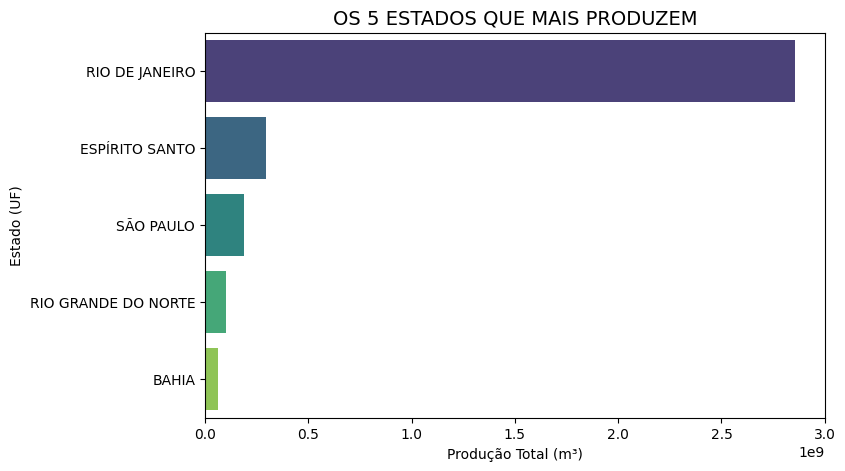

In [68]:
producao_por_estado = df.groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum()
mais_produzem = producao_por_estado.nlargest(5).reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(data = mais_produzem, x='PRODUÇÃO', y='UNIDADE DA FEDERAÇÃO', hue='UNIDADE DA FEDERAÇÃO', palette='viridis', legend=False)
plt.title('OS 5 ESTADOS QUE MAIS PRODUZEM', fontsize=14)
plt.xlabel('Produção Total (m³)')
plt.ylabel('Estado (UF)')
plt.show()

**Conclusão da análise**

Ao dar um "zoom" na Região Sudeste, vemos que o Rio de Janeiro é um gigante isolado, produzindo um volume esmagadoramente superior a qualquer outro estado. Espírito Santo e São Paulo vêm em seguida, confirmando a força da costa sudeste, enquanto Rio Grande do Norte e Bahia representam a resistência histórica da produção nordestina (principalmente em terra).

5. PRODUÇÃO DE PETRÓLEO POR REGIÃO

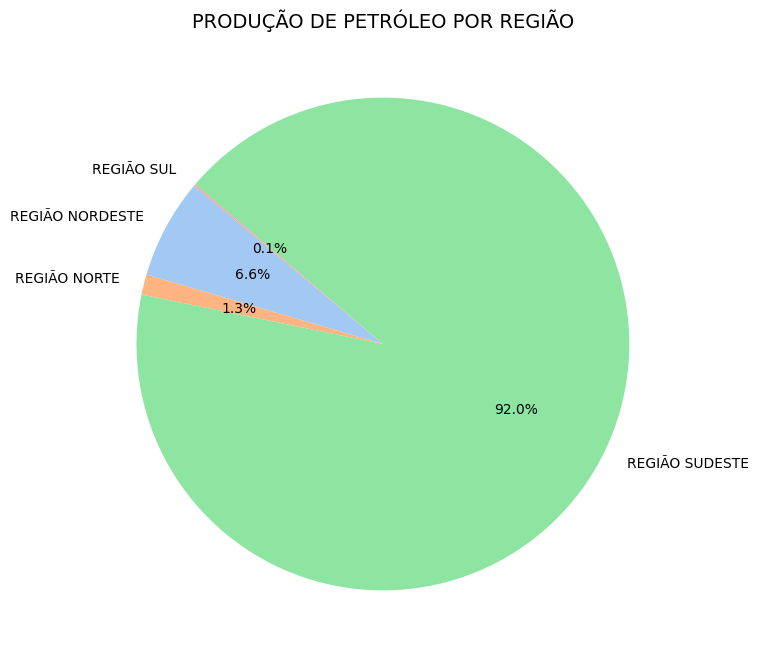

In [69]:

distri_regioes = df.groupby('GRANDE REGIÃO')['PRODUÇÃO'].sum()

plt.figure(figsize=(8, 8))
plt.pie(distri_regioes, labels=distri_regioes.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('PRODUÇÃO DE PETRÓLEO POR REGIÃO', fontsize=14)
plt.show()

**Conclusão da análise**

A segurança energética do país no setor de óleo e gás depende quase que exclusivamente de uma única região. Com 92% de toda a produção nacional concentrada no Sudeste, fica evidente que o Nordeste (6,6%), Norte (1,3%) e Sul (0,1%) possuem um papel apenas marginal ou focado em campos terrestres maduros e de menor volume.

5. MÉDIA DA PRODUÇÃO POR MÊS

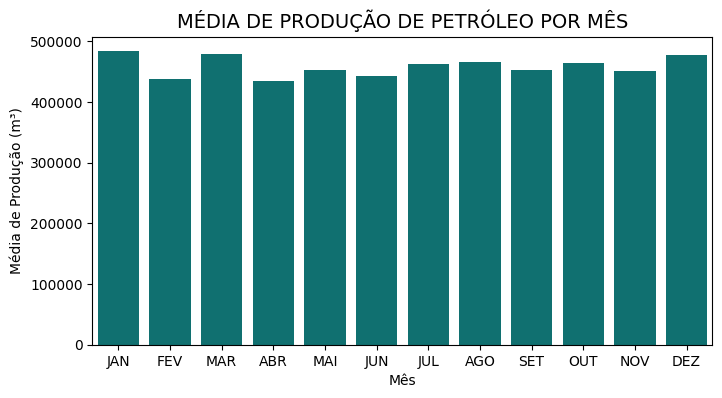

In [70]:
ordem_meses = ['JAN', 'FEV', 'MAR', 'ABR', 'MAI', 'JUN', 'JUL', 'AGO', 'SET', 'OUT', 'NOV', 'DEZ']
plt.figure(figsize=(8, 4))
prod_mensal = df.groupby('MÊS')['PRODUÇÃO'].mean().reindex(ordem_meses).reset_index()

sns.barplot(data=prod_mensal, x='MÊS', y='PRODUÇÃO', color='teal')
plt.title('MÉDIA DE PRODUÇÃO DE PETRÓLEO POR MÊS', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Média de Produção (m³)')
plt.show()

**Conclusão da análise**

A indústria petrolífera brasileira opera com altíssima consistência operacional e sem sazonalidade. Diferente do agronegócio (que depende de safras e clima) ou do varejo (que depende de datas comemorativas), as plataformas de petróleo extraem volumes muito semelhantes e estáveis de janeiro a dezembro, garantindo um fluxo contínuo de recursos.

7. INFORMAÇÕES SOBRE O ANO MAIS PRODUTIVO

In [71]:
prod_anual = df.groupby('ANO')['PRODUÇÃO'].sum().reset_index()

ano_recorde = prod_anual.loc[prod_anual['PRODUÇÃO'].idxmax()]['ANO']
total_recorde = prod_anual.loc[prod_anual['PRODUÇÃO'].idxmax()]['PRODUÇÃO']

df_ano_recorde = df[df['ANO'] == ano_recorde]
estado_lider = df_ano_recorde.groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum().idxmax()
prod_estado_lider = df_ano_recorde.groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum().max()

print(f"🏆 O RECORDE DE PRODUÇÃO ACONTECEU NO ANO DE: {int(ano_recorde)}")
print('------------------------------------------------------------------------------------')
print(f"📦A PRODUÇÃO TOTAL DO ANO QUE BATEU O RECORDE FOI: {total_recorde:,.2f} m³")
print('------------------------------------------------------------------------------------')
print(f"📌 O ESTADO MAIOR RESPONSÁVEL FOI {estado_lider}, COM {prod_estado_lider:,.2f} m³ PRODUZIDOS.")

🏆 O RECORDE DE PRODUÇÃO ACONTECEU NO ANO DE: 2025
------------------------------------------------------------------------------------
📦A PRODUÇÃO TOTAL DO ANO QUE BATEU O RECORDE FOI: 218,776,942.30 m³
------------------------------------------------------------------------------------
📌 O ESTADO MAIOR RESPONSÁVEL FOI RIO DE JANEIRO, COM 192,089,609.76 m³ PRODUZIDOS.


**Conclusão da análise**

O ano de 2025 foi o ápice histórico do setor no Brasil, superando 218 milhões de m³. O protagonismo absoluto do Rio de Janeiro (87,8% do total) coroa o sucesso dos investimentos de longo prazo no Pré-Sal e consolida o estado como o verdadeiro coração energético do país.

8. TENDÊNCIA DOS ESTADOS MAIORES PRODUTORES NOS ULTIMOS 5 ANOS

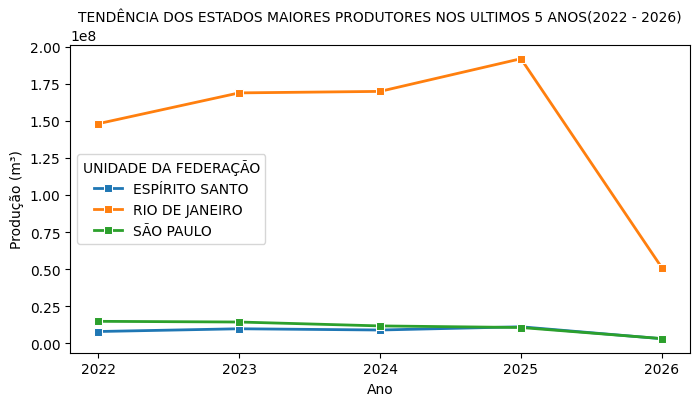

In [72]:
ultimo_ano = df['ANO'].max()
anos_recentes = list(range(int(ultimo_ano) - 4, int(ultimo_ano) + 1))

df_recente = df[df['ANO'].isin(anos_recentes)]
prod_recente = df_recente.groupby(['ANO', 'UNIDADE DA FEDERAÇÃO'])['PRODUÇÃO'].sum().reset_index()

melhores_estados_recentes = df_recente.groupby('UNIDADE DA FEDERAÇÃO')['PRODUÇÃO'].sum().nlargest(3).index
prod_recente_filtrado = prod_recente[prod_recente['UNIDADE DA FEDERAÇÃO'].isin(melhores_estados_recentes)]
plt.figure(figsize=(8, 4))
sns.lineplot(data=prod_recente_filtrado, x='ANO', y='PRODUÇÃO', hue='UNIDADE DA FEDERAÇÃO', marker='s', linewidth=2)
plt.title(f'TENDÊNCIA DOS ESTADOS MAIORES PRODUTORES NOS ULTIMOS 5 ANOS({df_recente["ANO"].min()} - {df_recente["ANO"].max()})', fontsize=10)
plt.xlabel('Ano')
plt.ylabel('Produção (m³)')
plt.xticks(anos_recentes)
plt.show()

**Conclusão da análise**

Analisando a história recente (2022 a 2025), notamos que o crescimento da produção nacional foi quase inteiramente "puxado" pelo estado do Rio de Janeiro, que manteve uma curva ascendente acentuada, enquanto Espírito Santo e São Paulo mantiveram suas produções estáveis. Novamente, a queda simultânea em 2026 confirma visualmente que se trata apenas da falta de consolidação dos meses restantes do ano na base de dados.



---



#**Conclusão**

A Análise Exploratória de Dados (EDA) permitiu transformar milhares de registros brutos em um diagnóstico claro e estratégico sobre o setor de petróleo no país:


*   **Domínio do Mar e do Sudeste:** A produção nacional é hiperconcentrada. O eixo marítimo do Sudeste (liderado isoladamente pelo Rio de Janeiro) opera em uma escala de bilhões de m³, tornando a produção terrestre do Norte/Nordeste um mercado importante regionalmente, mas marginal no volume total.

*   **Maturidade e Recordes:** O setor vive o seu melhor momento histórico. A curva ascendente consolidou o ano de 2025 como o ápice de produção da história, provando a eficiência tecnológica da exploração em águas profundas (Pré-Sal).

*   **Consistência Operacional:** Ao contrário de outros setores da economia, a extração de petróleo no Brasil é altamente estável, operando sem oscilações sazonais de janeiro a dezembro.

**Veredito Final:** Os dados mostram que o Brasil deixou de ser um produtor tradicional de terra para se tornar uma das maiores potências globais de tecnologia e exploração em alto-mar.